# Analysis of Repeated Antibiotics

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [5]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [6]:
def makeFilePath(pathFromWorkspace, fileName):
    workingdir = "/workspace/" if (os.name != "nt") else ""
    filepath = workingdir+pathFromWorkspace+fileName

    return filepath

In [7]:
# # reads all csv.gz files in the path without considering their dates
# import glob

# path = 'output/measures'
# all_files = glob.glob(path + "/*.csv.gz")

# data2019 = []

# for filename in all_files:
#     df = pd.read_csv(filename, index_col=None, header=0)
#     data2019.append(df)

# data = pd.concat(data2019, axis=0, ignore_index=True)

# data#.head()

In [8]:
data2019_month = {}
data2020_month = {}
data2021_month = {}
data2019 = []
data2020 = []
data2021 = []
for  i in range(1, 13):
    # data of 2019
    input_file_path = makeFilePath("output/repeat_ABs_data/", "input_repeat_ABs_2019-"+str(i).zfill(2)+"-01.csv.gz")
    data2019_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
    data2019.append(data2019_month["%s" %i])
    # data of 2020
    input_file_path = makeFilePath("output/repeat_ABs_data/", "input_repeat_ABs_2020-"+str(i).zfill(2)+"-01.csv.gz")
    data2020_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
    data2020.append(data2020_month["%s" %i])
    # data of 2021
    input_file_path = makeFilePath("output/repeat_ABs_data/", "input_repeat_ABs_2021-"+str(i).zfill(2)+"-01.csv.gz")
    data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
    data2021.append(data2021_month["%s" %i])
    
data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

data = data2019.append([data2020, data2021], ignore_index=True)

In [9]:
# data2019_month = {}
# data2020_month = {}
# data2021_month = {}
# data2019 = []
# data2020 = []
# data2021 = []
# for  i in range(1, 13):
#     # data of 2019
#     data2019_month["%s" %i] = pd.read_csv("output/measures/input_2019-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
#     data2019.append(data2019_month["%s" %i])
#     # data of 2020
#     data2020_month["%s" %i] = pd.read_csv("output/measures/input_2020-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
#     data2020.append(data2020_month["%s" %i])
#     # data of 2021
#     data2021_month["%s" %i] = pd.read_csv("output/measures/input_2021-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
#     data2021.append(data2021_month["%s" %i])
    
# data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
# data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
# data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# data = data2019.append([data2020, data2021], ignore_index=True)

In [10]:
data#.head()

,bmi_date_measured,smoking_status_date,most_recent_unclear_smoking_cat_date,flu_vaccine_med,flu_vaccine_clinical,sgss_positive,covadm1_dat,covadm2_dat,covrx1_dat,covrx2_dat,...,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,urti_ab_count_1,urti_ab_count_2,urti_ab_count_3,urti_ab_count_4,patient_id,date
0,NaN,2021-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,5,5,0,0,0,9075,2019-01-01
1,NaN,2019-02,2019-06,NaN,NaN,2019-08-08,NaN,NaN,NaN,NaN,...,0,3,5,0,0,6,0,5,4542,2019-01-01
2,2012-10,2020-08,2021-12,NaN,NaN,2019-07-12,NaN,NaN,NaN,NaN,...,0,0,0,0,0,5,0,0,570,2019-01-01
3,2019-11,NaN,NaN,2018-05,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,4,2324,2019-01-01
4,2012-12,NaN,2020-11,NaN,NaN,2020-03-08,NaN,NaN,NaN,NaN,...,0,0,0,0,5,0,0,0,2395,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,2018-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,4,5,0,0,3466,2021-12-01
35996,2010-06,2019-09,NaN,2018-02,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,4,5,5,0,0,3769,2021-12-01
35997,2012-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,5,0,6,0,0,0,8583,2021-12-01
35998,2011-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,4,2115,2021-12-01


In [11]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covadm1_dat', 'covadm2_dat',
       'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1', 'uti_ab_date_1',
       'uti_date_2', 'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3',
       'uti_date_4', 'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1',
       'lrti_date_2', 'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3',
       'lrti_date_4', 'lrti_ab_date_4', 'urti_date_1', 'urti_ab_date_1',
       'urti_date_2', 'urti_ab_date_2', 'urti_date_3', 'urti_ab_date_3',
       'urti_date_4', 'urti_ab_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions', 'antibacterial_brit',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'cov1snomed_dat', 'admitted

In [12]:
data.covadm2_dat.value_counts()

Series([], Name: covadm2_dat, dtype: int64)

In [13]:
# def read_csv_files(year):
#     data_month+str(year) = {}
#     data+str(year) = []
#     for i in range(1, 13):
#         # data of 2019
# #        data_month+str(year) = {}
#         if i <10:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-0"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-0"+str(i)+"-01"
#         else:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-"+str(i)+"-01"
#             data+str(year).append(data_month+str(year)["%s" %i])
        
#     data+str(year) = pd.concat(data_month+str(year), axis=0, ignore_index=True)

# #data = data2019.append([data2020, data2021], ignore_index=True)

In [14]:
# data2019_month = {}
# data2020_month = {}
# data2021_month = {}
# data2019 = []
# data2020 = []
# data2021 = []
# for  i in range(1, 13):
#     # data of 2019
#     input_file_path = makeFilePath("output/measures/", "input_2019-"+str(i).zfill(2)+"-01.csv.gz")
#     data2019_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
#     data2019.append(data2019_month["%s" %i])
#     # data of 2020
#     input_file_path = makeFilePath("output/measures/", "input_2020-"+str(i).zfill(2)+"-01.csv.gz")
#     data2020_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
#     data2020.append(data2020_month["%s" %i])
#     # data of 2021
#     input_file_path = makeFilePath("output/measures/", "input_2021-"+str(i).zfill(2)+"-01.csv.gz")
#     data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
#     data2021.append(data2021_month["%s" %i])
    
# data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
# data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
# data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# data = data2019.append([data2020, data2021], ignore_index=True)

In [15]:
# def read_csv_files(year):
#     #datamonth[year] = {}
#     # data2020_month = {}
#     # data2021_month = {}
#     #data[year] = []
#     # data2020 = []
#     # data2021 = []
#     data_month ={}
#     data=[]
#     for  i in range(1, 13):
#         input_file_path = makeFilePath("output/measures/", "input_"+str(year)+"-"+str(i).zfill(2)+"-01.csv.gz")
#         data_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#         data_month["%s" %i]['date'] = str(year)+"-"+str(i).zfill(2)+"-01"
#         data.append(data_month["%s" %i])
#     data = pd.concat(data_month["%s" %i], axis=0, ignore_index=True)
#     # data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
#     # data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# #data = data2019.append([data2020, data2021], ignore_index=True)

In [16]:
# read_csv_files(2019)

In [17]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covadm1_dat', 'covadm2_dat',
       'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1', 'uti_ab_date_1',
       'uti_date_2', 'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3',
       'uti_date_4', 'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1',
       'lrti_date_2', 'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3',
       'lrti_date_4', 'lrti_ab_date_4', 'urti_date_1', 'urti_ab_date_1',
       'urti_date_2', 'urti_ab_date_2', 'urti_date_3', 'urti_ab_date_3',
       'urti_date_4', 'urti_ab_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions', 'antibacterial_brit',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'cov1snomed_dat', 'admitted

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 80 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         28836 non-null  object 
 1   smoking_status_date                       3600 non-null   object 
 2   most_recent_unclear_smoking_cat_date      3600 non-null   object 
 3   flu_vaccine_med                           3600 non-null   object 
 4   flu_vaccine_clinical                      3600 non-null   object 
 5   sgss_positive                             3600 non-null   object 
 6   covadm1_dat                               0 non-null      float64
 7   covadm2_dat                               0 non-null      float64
 8   covrx1_dat                                0 non-null      float64
 9   covrx2_dat                                0 non-null      float64
 10  died_date                         

In [19]:
data.describe()

,covadm1_dat,covadm2_dat,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,...,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,urti_ab_count_1,urti_ab_count_2,urti_ab_count_3,urti_ab_count_4,patient_id
count,0.0,0.0,0.0,0.0,36000.000000,36000.000000,36000.000000,36000.000000,27000.000000,36000.000000,...,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,NaN,NaN,NaN,NaN,40.523417,24.501694,2.846611,22.478639,1.607259,3.318361,...,0.902667,0.898167,0.897833,0.898139,0.899000,0.898111,0.897250,0.903083,0.899111,4990.447083
std,NaN,NaN,NaN,NaN,23.771995,4.988795,1.521232,13.268983,1.291296,3.547765,...,1.864883,1.854695,1.854646,1.854356,1.857614,1.855874,1.853888,1.864808,1.855001,2880.965756
min,NaN,NaN,NaN,NaN,0.000000,5.000000,0.000000,-4.340063,1.000000,-5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,21.000000,21.000000,2.000000,15.885213,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2503.000000
50%,NaN,NaN,NaN,NaN,40.000000,24.000000,3.000000,25.522694,1.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.500000
75%,NaN,NaN,NaN,NaN,59.000000,28.000000,4.000000,31.929994,1.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7470.250000
max,NaN,NaN,NaN,NaN,109.000000,43.000000,5.000000,58.795853,5.000000,17.000000,...,9.000000,8.000000,8.000000,9.000000,8.000000,9.000000,8.000000,8.000000,8.000000,9999.000000


In [20]:
data.uti_date_1.value_counts()

2021-05-18    10
2021-06-10    10
2020-03-28    10
2021-02-02     9
2020-04-28     9
              ..
2021-07-05     1
2019-09-23     1
2020-07-15     1
2019-08-28     1
2021-10-19     1
Name: uti_date_1, Length: 1074, dtype: int64

In [21]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,0,NaN,0,NaN,0,NaN,5
1,NaN,0,NaN,3,NaN,5,NaN,0
2,NaN,0,NaN,0,NaN,0,NaN,0
3,NaN,0,NaN,0,2019-08-30,0,NaN,0
4,NaN,0,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
35995,NaN,0,NaN,0,2019-12-25,0,NaN,0
35996,NaN,0,NaN,0,NaN,0,NaN,4
35997,NaN,0,NaN,0,NaN,5,NaN,0
35998,NaN,0,NaN,0,NaN,0,NaN,0


In [22]:
#data.loc[:, ['urti_date_1', 'urti_ab_count_1', 'urti_date_2', 'urti_ab_count_2', 'urti_date_3', 'urti_ab_count_3', 'urti_date_4', 'urti_ab_count_4']]

In [23]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,0,NaN,4,NaN,0
1,NaN,0,NaN,4,NaN,0,NaN,0
2,2021-02-28,0,NaN,0,NaN,0,NaN,0
3,NaN,0,NaN,0,NaN,0,NaN,0
4,NaN,0,NaN,0,NaN,6,NaN,6
...,...,...,...,...,...,...,...,...
35995,NaN,4,NaN,0,NaN,0,NaN,0
35996,NaN,4,NaN,5,NaN,0,NaN,0
35997,2021-07-01,0,NaN,5,NaN,0,NaN,0
35998,NaN,5,NaN,0,NaN,0,NaN,0


In [24]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [25]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [26]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [27]:
data['urti_date_1'] = pd.to_datetime(data['urti_date_1'], format='%Y-%m-%d', errors='ignore')
data['urti_date_2'] = pd.to_datetime(data['urti_date_2'], format='%Y-%m-%d', errors='ignore')
data['urti_date_3'] = pd.to_datetime(data['urti_date_3'], format='%Y-%m-%d', errors='ignore')
data['urti_date_4'] = pd.to_datetime(data['urti_date_4'], format='%Y-%m-%d', errors='ignore')

In [28]:
# data['uti_ab_date_1'] = pd.to_datetime(data['uti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_2'] = pd.to_datetime(data['uti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_3'] = pd.to_datetime(data['uti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_4'] = pd.to_datetime(data['uti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

# data['lrti_ab_date_1'] = pd.to_datetime(data['lrti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_2'] = pd.to_datetime(data['lrti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_3'] = pd.to_datetime(data['lrti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_4'] = pd.to_datetime(data['lrti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

In [29]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1

#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [30]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [31]:
# data['repeated_ABs'].value_counts()

## 2- Cox model
### 2-1- Entire data

In [32]:
import math
from lifelines import CoxPHFitter
from lifelines.calibration import survival_probability_calibration

In [33]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days < 190:
#                 n=(data.iat[idx,col6]-data.iat[idx,col5]).days
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days < 190:
#                 n=(data.iat[idx,col7]-data.iat[idx,col6]).days
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days < 190:
#                 n=(data.iat[idx,col8]-data.iat[idx,col7]).days

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days < 190:
#                 n=(data.iat[idx,col5]-data.iat[idx,col13]).days
#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days < 190:
#                 n=(data.iat[idx,col14]-data.iat[idx,col13]).days
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days < 190:
#                 n=(data.iat[idx,col15]-data.iat[idx,col14]).days
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days < 190:
#                 n=(data.iat[idx,col16]-data.iat[idx,col15]).days
    
#     data.iat[idx, col0]=n

# data['repeated_ABs'].value_counts()

In [34]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

col17 = data.columns.get_loc('urti_ab_count_1')
col18 = data.columns.get_loc('urti_ab_count_2')
col19 = data.columns.get_loc('urti_ab_count_3')
col20 = data.columns.get_loc('urti_ab_count_4')

col21 = data.columns.get_loc('urti_date_1')
col22 = data.columns.get_loc('urti_date_2')
col23 = data.columns.get_loc('urti_date_3')
col24 = data.columns.get_loc('urti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=0

    #uti
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col6]-data.iat[idx,col5]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col7]-data.iat[idx,col6]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col8]-data.iat[idx,col7]).days

    #lrti
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days < 30:
                n=(data.iat[idx,col14]-data.iat[idx,col13]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days < 30:
                n=(data.iat[idx,col15]-data.iat[idx,col14]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days < 30:
                n=(data.iat[idx,col16]-data.iat[idx,col15]).days

    #urti
    if data.iat[idx, col18] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col21]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col21]).days
    if data.iat[idx, col19] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col22]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col22]).days
    if data.iat[idx, col20] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col23]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col23]).days

    #uti and lrti
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col13]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col13]-data.iat[idx,col5]).days    
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col14]-data.iat[idx,col5]).days
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col15]-data.iat[idx,col5]).days
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col12] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col16]-data.iat[idx,col5]).days

    if data.iat[idx, col2] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col13]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col13]-data.iat[idx,col6]).days    
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col14]-data.iat[idx,col6]).days
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col15]-data.iat[idx,col6]).days
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col12] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col16]-data.iat[idx,col6]).days

    if data.iat[idx, col3] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col13]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col13]-data.iat[idx,col7]).days    
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col14]-data.iat[idx,col7]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col15]-data.iat[idx,col7]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col12] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col16]-data.iat[idx,col7]).days

    if data.iat[idx, col4] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col13]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col13]-data.iat[idx,col8]).days    
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col14]-data.iat[idx,col8]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col15]-data.iat[idx,col8]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col12] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col16]-data.iat[idx,col8]).days

    #uti and urti
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col5]).days    
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col5]).days
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col5]).days
    if data.iat[idx, col1] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col5]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col5]).days

    if data.iat[idx, col2] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col6]).days    
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col6]).days
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col6]).days
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col6]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col6]).days

    if data.iat[idx, col3] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col7]).days    
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col7]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col7]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col7]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col7]).days

    if data.iat[idx, col4] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col8]).days    
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col8]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col8]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col8]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col8]).days

    #lrti and urti
    if data.iat[idx, col9] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col13]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col13]).days    
    if data.iat[idx, col9] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col13]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col13]).days
    if data.iat[idx, col9] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col13]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col13]).days
    if data.iat[idx, col9] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col13]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col13]).days

    if data.iat[idx, col10] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col14]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col14]).days    
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col14]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col14]).days
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col14]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col14]).days
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col14]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col14]).days

    if data.iat[idx, col11] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col15]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col15]).days    
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col15]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col15]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col15]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col15]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col15]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col15]).days

    if data.iat[idx, col12] > 0:
        if data.iat[idx, col17] > 0:
            if (data.iat[idx,col21]-data.iat[idx,col16]).days < 30:
                n=(data.iat[idx,col21]-data.iat[idx,col16]).days    
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col18] > 0:
            if (data.iat[idx,col22]-data.iat[idx,col16]).days < 30:
                n=(data.iat[idx,col22]-data.iat[idx,col16]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col19] > 0:
            if (data.iat[idx,col23]-data.iat[idx,col16]).days < 30:
                n=(data.iat[idx,col23]-data.iat[idx,col16]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col20] > 0:
            if (data.iat[idx,col24]-data.iat[idx,col16]).days < 30:
                n=(data.iat[idx,col24]-data.iat[idx,col16]).days
    
    data.iat[idx, col0]=n

data['repeated_ABs'].value_counts()

 0.0      35591
-76.0         4
-340.0        4
-764.0        4
-133.0        3
          ...  
 12.0         1
-645.0        1
-524.0        1
-385.0        1
-760.0        1
Name: repeated_ABs, Length: 321, dtype: int64

In [35]:
# replace any values smaller than -90
a = np.array(data['repeated_ABs'].values.tolist())
data['repeated_ABs'] = np.where(a < -30, np.nan, a).tolist()

# calculate absolute values for all rows in repeated_ABs column
data['repeated_ABs_time'] = data['repeated_ABs'].abs()

data['repeated_ABs_time'].value_counts()

0.0     35591
27.0        4
24.0        3
9.0         3
13.0        3
6.0         2
25.0        2
26.0        2
17.0        2
1.0         2
23.0        2
15.0        2
30.0        2
20.0        1
3.0         1
28.0        1
21.0        1
14.0        1
12.0        1
11.0        1
10.0        1
18.0        1
7.0         1
5.0         1
8.0         1
29.0        1
4.0         1
Name: repeated_ABs_time, dtype: int64

In [36]:
data['repeated_ABs_binary'] = data['repeated_ABs_time'].mask(data['repeated_ABs_time'] > 0, 1)

data['repeated_ABs_binary'].value_counts()

0.0    35591
1.0       43
Name: repeated_ABs_binary, dtype: int64

In [37]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covadm1_dat', 'covadm2_dat',
       'covrx1_dat', 'covrx2_dat', 'died_date', 'uti_date_1', 'uti_ab_date_1',
       'uti_date_2', 'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3',
       'uti_date_4', 'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1',
       'lrti_date_2', 'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3',
       'lrti_date_4', 'lrti_ab_date_4', 'urti_date_1', 'urti_ab_date_1',
       'urti_date_2', 'urti_ab_date_2', 'urti_date_3', 'urti_ab_date_3',
       'urti_date_4', 'urti_ab_date_4', 'age', 'age_cat', 'sex', 'practice',
       'region', 'msoa', 'imd', 'bmi', 'ethnicity', 'smoking_status',
       'gp_count', 'flu_vaccine_tpp', 'flu_vaccine',
       'antibacterial_prescriptions', 'antibacterial_brit',
       'broad_spectrum_antibiotics_prescriptions', 'primary_care_covid',
       'cov1snomed_dat', 'admitted

In [38]:
data.covrx1_dat.value_counts()

Series([], Name: covrx1_dat, dtype: int64)

In [39]:
cph = CoxPHFitter()
Cox_data = data[['repeated_ABs_time', 'repeated_ABs_binary', 'age', 'age_cat', 'sex', 'bmi', 'imd', 'flu_vaccine', 'gp_count', 'antibacterial_prescriptions']]

# printing number of missing values in each variable 
Cox_data.isnull().sum()

repeated_ABs_time              366
repeated_ABs_binary            366
age                              0
age_cat                          0
sex                              0
bmi                              0
imd                              0
flu_vaccine                      0
gp_count                         0
antibacterial_prescriptions      0
dtype: int64

In [40]:
Cox_data = Cox_data.dropna(axis='rows')
Cox_data.isnull().sum()

repeated_ABs_time              0
repeated_ABs_binary            0
age                            0
age_cat                        0
sex                            0
bmi                            0
imd                            0
flu_vaccine                    0
gp_count                       0
antibacterial_prescriptions    0
dtype: int64

In [41]:
print(Cox_data.shape)

(35634, 10)


In [42]:
Cox_data.repeated_ABs_binary.value_counts()

0.0    35591
1.0       43
Name: repeated_ABs_binary, dtype: int64

In [43]:
cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex + bmi + imd + flu_vaccine + gp_count + antibacterial_prescriptions")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 35634 total observations, 35591 right-censored observations>
             duration col = 'repeated_ABs_time'
                event col = 'repeated_ABs_binary'
      baseline estimation = breslow
   number of observations = 35634
number of events observed = 43
   partial log-likelihood = -119.28
         time fit was run = 2022-01-14 11:41:16 UTC

---
                              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                           
age                           0.00       1.00       0.01            -0.01             0.02                 0.99                 1.02
antibacterial_prescriptions   0.13       1.14       0.12            -0.12             0.37                 0.89                 1.45
bmi                           0.00       1.00       0.01            -0.02             0.03                 0.98                 1.03
flu_vaccine                   0.27       1.31       0.45            -0.62             1.15                 0.54                 3.16
gp_count                      0.05       1.05       0.05            -0.05             0.14                 0.95                 1.16
imd                          -0.14       0.87       0.13            -0.40             0.12                 0.67                 1.13
sex[T.M]                     -0.48       0.62       0.33            -1.13             0.18                 0.32                 1.20

                                z    p   -log2(p)
covariate                                        
age                          0.56 0.57       0.80
antibacterial_prescriptions  1.03 0.30       1.72
bmi                          0.06 0.95       0.07
flu_vaccine                  0.59 0.55       0.85
gp_count                     0.92 0.36       1.49
imd                         -1.07 0.28       1.82
sex[T.M]                    -1.43 0.15       2.70
---
Concordance = 0.59
Partial AIC = 252.56
log-likelihood ratio test = 4.50 on 7 df
-log2(p) of ll-ratio test = 0.47

In [92]:
# cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="sex + flu_vaccine + imd")
# cph.print_summary()

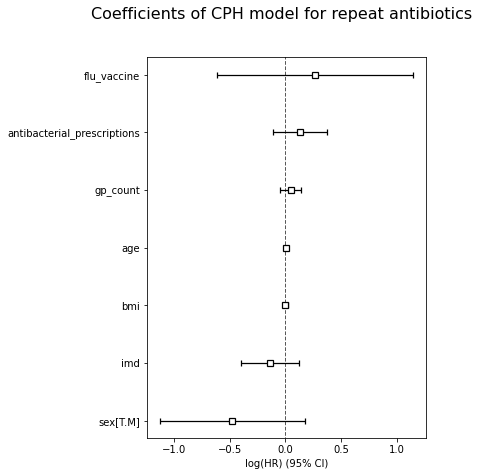

In [44]:
fig, ax = plt.subplots(figsize=(5, 7))
cph.plot()
plt.suptitle('Coefficients of CPH model for repeat antibiotics', fontsize=16)
#_ = ax.set_yticklabels(['Age', 'BMI', 'GP consultations', 'CCI', 'IMD', 'Flu vaccine', 'Antibacterial prescriptions'], 
#                        rotation=45, fontsize=12, ha='right')
plt.savefig('../output/repeat_ABs_outputs/coefficients_cph_repeat_antibiotics.jpg')
plt.show()

In [1]:
# cph.plot_partial_effects_on_outcome(covariates='sex', 
#                                     values=['F', 'M'], 
#                                     cmap='coolwarm',
#                                     plot_baseline=False)
# plt.suptitle('Effect of covariate sex on CPH model for repeat antibiotics', fontsize=16)
# plt.savefig('../output/repeat_ABs_outputs/repeatedABs_effect_covariate_sex.jpg')
# plt.show()

In [2]:
# Cox_data['flu_vaccine'] = Cox_data['flu_vaccine'].astype("category")
# #Cox_data['age'] = Cox_data['age'].astype("category")
# Cox_data['imd'] = Cox_data['imd'].astype("category")
# # Cox_data['bmi'] = Cox_data['bmi'].astype("category")
# # Cox_data['gp_count'] = Cox_data['gp_count'].astype("category")
# # Cox_data['antibacterial_prescriptions'] = Cox_data['antibacterial_prescriptions'].astype("category")

In [411]:
# cph.plot_partial_effects_on_outcome(covariates='flu_vaccine', 
#                                     values=[0, 1], 
#                                     cmap='coolwarm',
#                                     plot_baseline=False)
# plt.suptitle('Effect of covariate flu vaccination', fontsize=16)
# #plt.savefig('../output/repeat_ABs_outputs/repeatedABs_effect_covariate_flu_vaccine.jpg')
# plt.show()

In [412]:
# cph.plot_partial_effects_on_outcome(covariates='imd', 
#                                     values=[0, 1, 2, 3, 4, 5], 
#                                     cmap='coolwarm',
#                                     plot_baseline=False)
# plt.suptitle('Effect of covariate flu vaccination', fontsize=16)
# #plt.savefig('../output/repeat_ABs_outputs/repeatedABs_effect_covariate_flu_vaccine.jpg')
# plt.show()

### 2-2- Data before pandemic

In [50]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d', errors='ignore')

In [63]:
data_before_pancemic = data[data['date'] <= '2019-12-01']
data_before_pancemic.shape

(12000, 83)

In [64]:
cph_before_pandemic = CoxPHFitter()
Cox_data_before_pancemic = data_before_pancemic[['repeated_ABs_time', 'repeated_ABs_binary', 'age', 'age_cat', 'sex', 'bmi', 'imd', 'flu_vaccine', 'gp_count', 'antibacterial_prescriptions']]

# printing number of missing values in each variable 
Cox_data_before_pancemic.isnull().sum()

repeated_ABs_time              130
repeated_ABs_binary            130
age                              0
age_cat                          0
sex                              0
bmi                              0
imd                              0
flu_vaccine                      0
gp_count                         0
antibacterial_prescriptions      0
dtype: int64

In [65]:
Cox_data_before_pancemic = Cox_data_before_pancemic.dropna(axis='rows')
Cox_data_before_pancemic.isnull().sum()

repeated_ABs_time              0
repeated_ABs_binary            0
age                            0
age_cat                        0
sex                            0
bmi                            0
imd                            0
flu_vaccine                    0
gp_count                       0
antibacterial_prescriptions    0
dtype: int64

In [71]:
cph_before_pandemic.fit(Cox_data_before_pancemic, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex + bmi + imd + flu_vaccine + gp_count + antibacterial_prescriptions")
cph_before_pandemic.print_summary()

<lifelines.CoxPHFitter: fitted with 11870 total observations, 11854 right-censored observations>
             duration col = 'repeated_ABs_time'
                event col = 'repeated_ABs_binary'
      baseline estimation = breslow
   number of observations = 11870
number of events observed = 16
   partial log-likelihood = -24.18
         time fit was run = 2022-01-14 13:59:10 UTC

---
                              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                           
age                           0.01       1.01       0.02            -0.03             0.06                 0.97                 1.06
antibacterial_prescriptions  -0.55       0.58       0.37            -1.27             0.17                 0.28                 1.19
bmi                           0.03       1.03       0.04            -0.05             0.10                 0.96                 1.10
flu_vaccine                  -0.57       0.57       1.17            -2.87             1.73                 0.06                 5.64
gp_count                      0.13       1.14       0.11            -0.09             0.36                 0.91                 1.43
imd                          -0.76       0.47       0.27            -1.28            -0.24                 0.28                 0.79
sex[T.M]                      0.65       1.92       1.01            -1.33             2.64                 0.26                14.01

                                z      p   -log2(p)
covariate                                          
age                          0.67   0.50       0.99
antibacterial_prescriptions -1.49   0.14       2.87
bmi                          0.71   0.48       1.06
flu_vaccine                 -0.49   0.63       0.67
gp_count                     1.17   0.24       2.04
imd                         -2.86 <0.005       7.90
sex[T.M]                     0.65   0.52       0.95
---
Concordance = 0.84
Partial AIC = 62.36
log-likelihood ratio test = 12.99 on 7 df
-log2(p) of ll-ratio test = 3.79

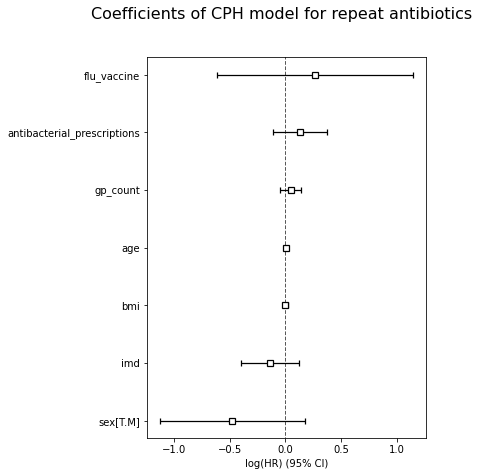

In [67]:
fig, ax = plt.subplots(figsize=(5, 7))
cph_before_pandemic.plot()
plt.suptitle('Coefficients of CPH model for repeat antibiotics before the pandemic', fontsize=16)
#_ = ax.set_yticklabels(['Age', 'BMI', 'GP consultations', 'CCI', 'IMD', 'Flu vaccine', 'Antibacterial prescriptions'], 
#                        rotation=45, fontsize=12, ha='right')
plt.savefig('../output/repeat_ABs_outputs/coefficients_cph_repeat_antibiotics_before_pandemic.jpg')
plt.show()

### 2-3- Data after pandemic

In [68]:
data_after_pancemic = data[data['date'] >= '2020-03-01']
data_after_pancemic.shape

(22000, 83)

In [69]:
cph_after_pandemic = CoxPHFitter()
Cox_data_after_pancemic = data_after_pancemic[['repeated_ABs_time', 'repeated_ABs_binary', 'age', 'age_cat', 'sex', 'bmi', 'imd', 'flu_vaccine', 'gp_count', 'antibacterial_prescriptions']]

# printing number of missing values in each variable 
Cox_data_after_pancemic.isnull().sum()

repeated_ABs_time              221
repeated_ABs_binary            221
age                              0
age_cat                          0
sex                              0
bmi                              0
imd                              0
flu_vaccine                      0
gp_count                         0
antibacterial_prescriptions      0
dtype: int64

In [70]:
Cox_data_after_pancemic = Cox_data_after_pancemic.dropna(axis='rows')
Cox_data_after_pancemic.isnull().sum()

repeated_ABs_time              0
repeated_ABs_binary            0
age                            0
age_cat                        0
sex                            0
bmi                            0
imd                            0
flu_vaccine                    0
gp_count                       0
antibacterial_prescriptions    0
dtype: int64

In [72]:
cph_after_pandemic.fit(Cox_data_after_pancemic, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex + bmi + imd + flu_vaccine + gp_count + antibacterial_prescriptions")
cph_after_pandemic.print_summary()

<lifelines.CoxPHFitter: fitted with 21779 total observations, 21753 right-censored observations>
             duration col = 'repeated_ABs_time'
                event col = 'repeated_ABs_binary'
      baseline estimation = breslow
   number of observations = 21779
number of events observed = 26
   partial log-likelihood = -55.86
         time fit was run = 2022-01-14 13:59:31 UTC

---
                              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                           
age                          -0.02       0.98       0.01            -0.05             0.01                 0.95                 1.01
antibacterial_prescriptions   0.44       1.55       0.18             0.08             0.80                 1.08                 2.22
bmi                          -0.00       1.00       0.02            -0.03             0.03                 0.97                 1.03
flu_vaccine                   1.26       3.51       0.66            -0.05             2.56                 0.95                12.93
gp_count                      0.11       1.11       0.07            -0.03             0.25                 0.97                 1.28
imd                          -0.29       0.75       0.22            -0.72             0.14                 0.49                 1.15
sex[T.M]                     -0.43       0.65       0.50            -1.41             0.55                 0.24                 1.74

                                z    p   -log2(p)
covariate                                        
age                         -1.38 0.17       2.58
antibacterial_prescriptions  2.40 0.02       5.93
bmi                         -0.06 0.95       0.08
flu_vaccine                  1.89 0.06       4.09
gp_count                     1.49 0.14       2.88
imd                         -1.32 0.19       2.42
sex[T.M]                    -0.86 0.39       1.35
---
Concordance = 0.66
Partial AIC = 125.72
log-likelihood ratio test = 10.81 on 7 df
-log2(p) of ll-ratio test = 2.76

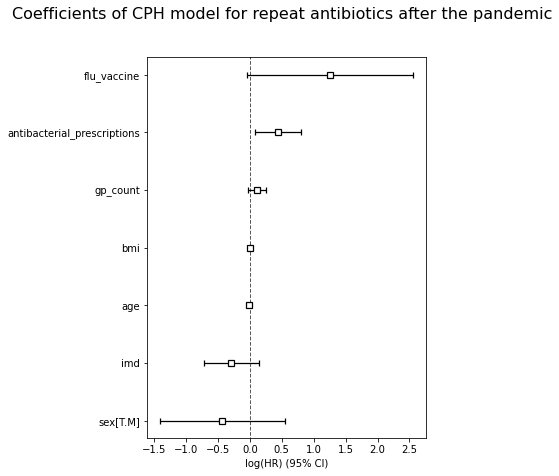

In [73]:
fig, ax = plt.subplots(figsize=(5, 7))
cph_after_pandemic.plot()
plt.suptitle('Coefficients of CPH model for repeat antibiotics after the pandemic', fontsize=16)
#_ = ax.set_yticklabels(['Age', 'BMI', 'GP consultations', 'CCI', 'IMD', 'Flu vaccine', 'Antibacterial prescriptions'], 
#                        rotation=45, fontsize=12, ha='right')
plt.savefig('../output/repeat_ABs_outputs/coefficients_cph_repeat_antibiotics_after_pandemic.jpg')
plt.show()

In [48]:
# from lifelines.calibration import survival_probability_calibration

# cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex")

# #plt.figure()

# survival_probability_calibration(cph, Cox_data, t0=90)
# #survival_probability_calibration(cph, dataCox, t0=70)

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?
- Convergence errors pop. See https://lifelines.readthedocs.io/en/latest/Examples.html.